In [50]:
import matplotlib.pyplot as plt
import shutil


fontsi = 15
if shutil.which("latex") is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']  # explicitly specify CM
plt.rc('image', interpolation='none')


<>:28: SyntaxWarning: invalid escape sequence '\;'
<>:29: SyntaxWarning: invalid escape sequence '\;'
<>:28: SyntaxWarning: invalid escape sequence '\;'
<>:29: SyntaxWarning: invalid escape sequence '\;'
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_4258/1511339079.py:28: SyntaxWarning: invalid escape sequence '\;'
  axes[i].plot(tp[:, 0], tp[:, 1], label=f"$T_+,\;n={i+1}$", ls = "--", color = "black")
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_4258/1511339079.py:29: SyntaxWarning: invalid escape sequence '\;'
  axes[i].plot(tm[:, 0], tm[:, 1], label=f"$T_-,\;n={i+1}$", ls = "-", color = "black")


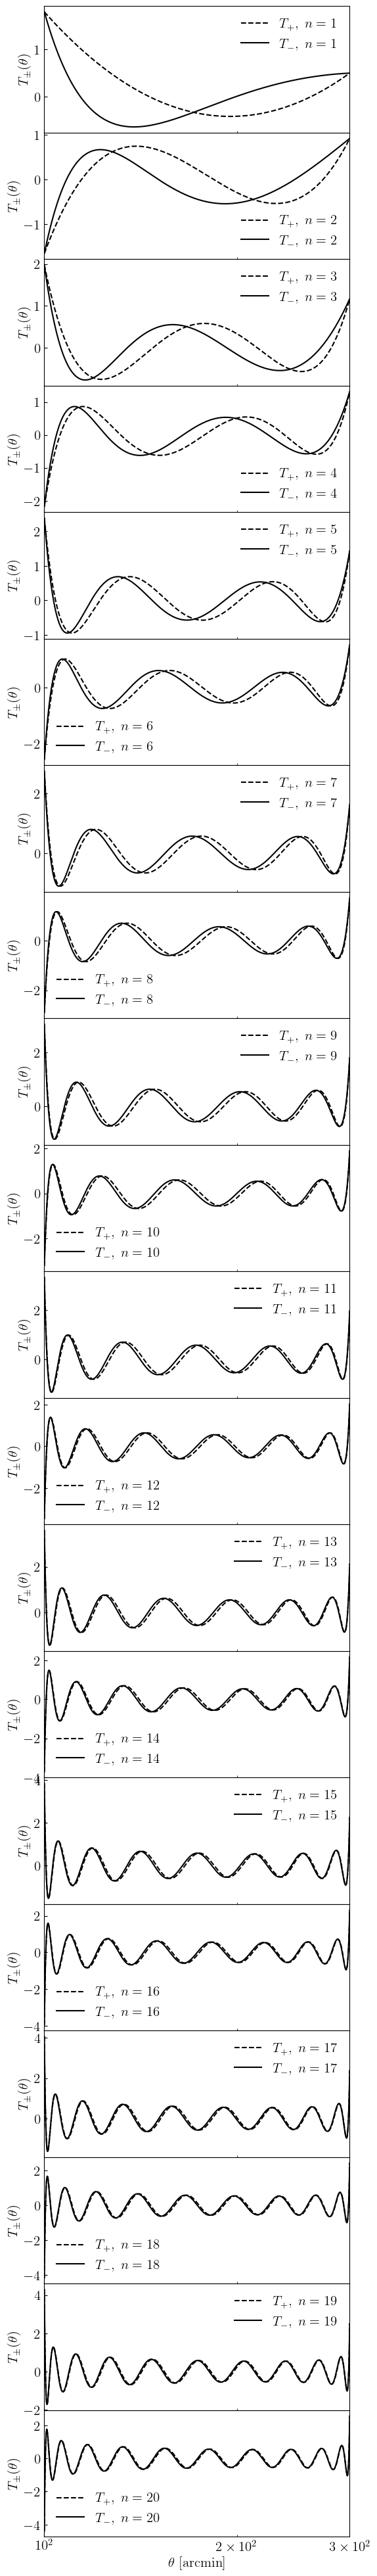

In [51]:
import numpy as np
import glob
from pathlib import Path

benchmarks_dir = Path("./../benchmarks_cosebis")
tmin = 100.0
tmax = 300.0
arcmintorad = 1. / 60 * np.pi / 180


# --- Load files ---
tp_files = sorted(benchmarks_dir.glob(f"Tp_benchmark_{tmin}_{tmax}_mode_*.txt"))
tm_files = sorted(benchmarks_dir.glob(f"Tm_benchmark_{tmin}_{tmax}_mode_*.txt"))



well_files = sorted(benchmarks_dir.glob(f"Well_{tmin}_{tmax}_mode_*.txt"))

Tp_data = [np.loadtxt(f) for f in tp_files]
Tm_data = [np.loadtxt(f) for f in tm_files]
Well_data = [np.loadtxt(f) for f in well_files]


Nmodes = len(Tp_data)
# --- T+ and T- ---
fig, axes = plt.subplots(Nmodes, 1, figsize=(6, 2.5*Nmodes), sharex=True)
for i, (tp, tm) in enumerate(zip(Tp_data, Tm_data)):
    axes[i].plot(tp[:, 0], tp[:, 1], label=f"$T_+,\;n={i+1}$", ls = "--", color = "black")
    axes[i].plot(tm[:, 0], tm[:, 1], label=f"$T_-,\;n={i+1}$", ls = "-", color = "black")
    axes[i].set_ylabel(r"$T_\pm(\theta)$", fontsize=fontsi )
    if i == Nmodes - 1:
        axes[i].set_xlabel(r"$\theta\; [\mathrm{arcmin}]$", fontsize=fontsi)
    if i < Nmodes - 1:
        axes[i].tick_params(labelbottom=False)
    axes[i].set_xlim(tmin, tmax)
for ax in axes:
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='both', direction='in', labelsize=fontsi)
    ax.legend(fontsize=fontsi, loc="best", frameon=False)

fig.subplots_adjust(hspace=0.)
plt.savefig(f"Tp_Tm_benchmarks_tmin{tmin}_tmax{tmax}.pdf", bbox_inches="tight")
plt.show()



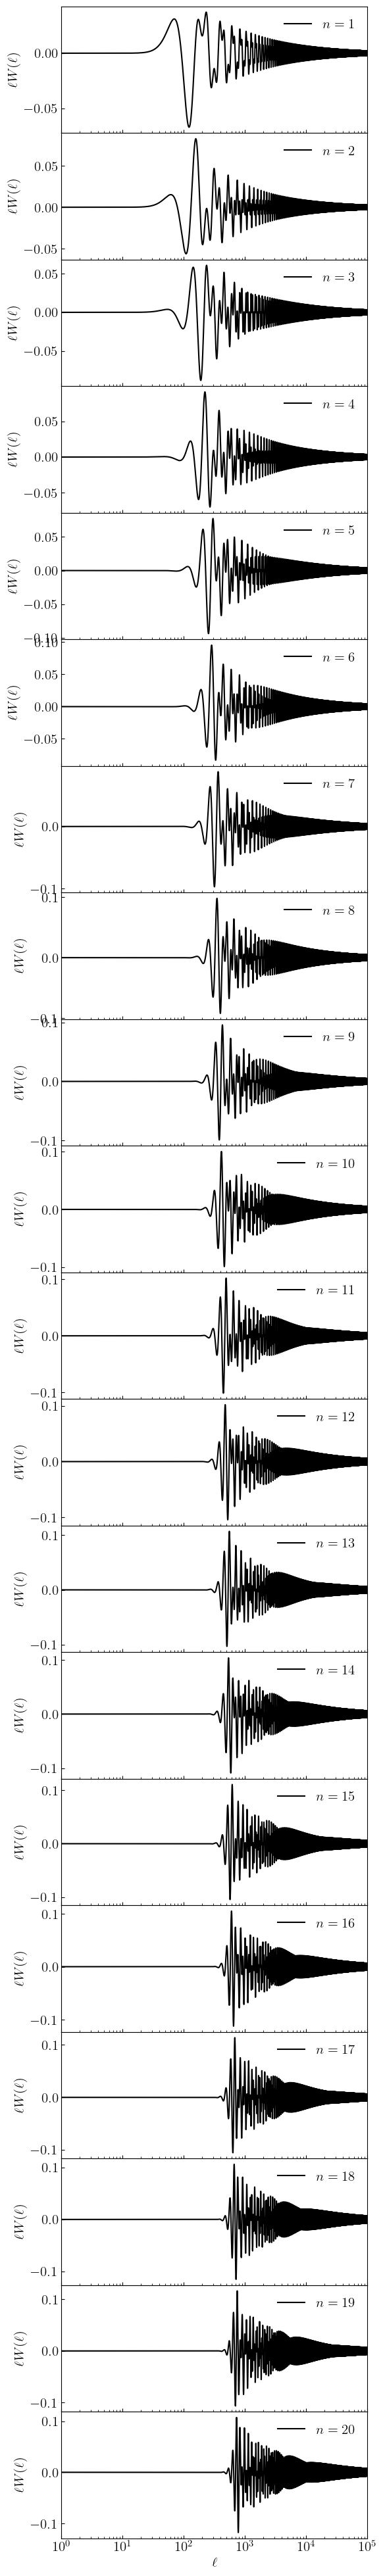

In [52]:

# --- W(ell) ---
fig, axes = plt.subplots(Nmodes,1, figsize=(6, 2.5*Nmodes), sharex=True)
for i, well in enumerate(Well_data):
    axes[i].plot(well[:, 0], well[:, 0]*well[:, 1], label=f"$n={i+1}$", color = "black")
    axes[i].set_ylabel(r"$\ell W(\ell)$", fontsize=fontsi)
    axes[i].set_xlim(well[0, 0], well[-1, 0])
    if i == Nmodes - 1:
        axes[i].set_xlabel(r"$\ell$", fontsize=fontsi)
    if i < Nmodes - 1:
        axes[i].tick_params(labelbottom=False)

for ax in axes:
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='both', direction='in', labelsize=fontsi)
    ax.legend(fontsize=fontsi, loc="best", frameon=False)
fig.subplots_adjust(hspace=0.)
plt.savefig(f"Well_benchmarks_tmin{tmin}_tmax{tmax}.pdf", bbox_inches="tight")
plt.show()
